# **Notebook**

# **1. Introduction**

This notebook presents a data science workflow analysing the relationship between air pollution, socio-economic inequality, and health outcomes across UK local authorities.

The objective is to investigate whether PM2.5 significantly affects respiratory health and how this relationship is influenced by socio-economic deprivation and population density.

This analysis follows a structured workflow including data preparation, exploratory analysis, modelling, validation, and spatial visualisation.

# **2. Data Sources**

The analysis integrates multiple datasets:

- PM2.5 data (DEFRA) → environmental exposure  https://uk-air.defra.gov.uk/data/pcm-data
- IMD data → socio-economic inequality
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019
- Population density (ONS) → urban structure
https://www.nomisweb.co.uk/query/construct/submit.asp?menuopt=201&subcomp=  
- Health (respiratory mortality) → outcome variable https://fingertips.phe.org.uk/search/respiratory%20mortality#page/9/gid/1/pat/6/par/E12000001/ati/501/are/E06000047/iid/40701/age/163/sex/4/cat/-1/ctp/-1/yrr/1/cid/4/tbm/1

These datasets are aggregated at Local Authority level to ensure consistency.

In [113]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# **3. Data Loading**

In [114]:
f2019 = pd.read_csv("/content/popwmpm252019byUKlocalauthority.csv")
f2020 = pd.read_csv("/content/popwmpm252020byUKlocalauthority.csv")
f2021 = pd.read_csv("/content/popwmpm252021byUKlocalauthority.csv")
f2022 = pd.read_csv("/content/popwmpm252022byUKlocalauthority.csv")
f2023 = pd.read_csv("/content/popwmpm252023byUKlocalauthority.csv")

In [115]:
f2019

,population-weighted annual mean PM2.5 concentration for 2019 (ugm-3),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,The anthropogenic component should be used for...,NaN,NaN,NaN,NaN
1,LA code,PM2.5 2019 (total),PM2.5 2019 (non-anthropogenic),PM2.5 2019 (anthropogenic),Local Authority
2,1,9.6324,0.567,9.0653,Adur
3,2,4.814,0.3255,4.4886,Allerdale
4,4,9.6358,0.514,9.1218,Amber Valley
...,...,...,...,...,...
380,460,7.3799,0.5907,6.7892,Dorset
381,461,9.6553,0.535,9.1203,East Suffolk
382,462,9.8498,0.5275,9.3223,West Suffolk
383,463,7.572,0.6603,6.9117,Somerset West and Taunton


# **4. Data Cleaning**

Raw datasets often contain inconsistent column names, missing values, and formatting issues.

Cleaning ensures that variables are standardised and ready for merging and analysis.

In [116]:
def load_pm25(file, year):
    # Step 1: read CSV file and skip first metadata row
    df = pd.read_csv(file, skiprows=1)

    # Step 2: use first row as column names
    df.columns = df.iloc[0]

    # Step 3: drop the first row (now duplicated header)
    df = df[1:].reset_index(drop=True)

    # Step 4: clean column names (remove spaces)
    df.columns = df.columns.str.strip()

    # Step 5: keep only relevant columns
    df = df[["LA code", f"PM2.5 {year} (total)"]]

    # Step 6: rename columns for consistency across years
    df = df.rename(columns={
        "LA code": "LA_code",
        f"PM2.5 {year} (total)": f"pm25_{year}"
    })

    # Step 7: convert PM2.5 values to numeric (handle errors)
    df[f"pm25_{year}"] = pd.to_numeric(df[f"pm25_{year}"], errors="coerce")

    return df

This function standardises PM2.5 datasets by:

- Removing unnecessary header rows  
- Selecting relevant columns  
- Renaming variables consistently  
- Converting values to numeric format  

This ensures that PM2.5 data from different years can be easily merged and compared.


In [117]:
f2019 = load_pm25("/content/popwmpm252019byUKlocalauthority.csv", 2019)
f2020 = load_pm25("/content/popwmpm252020byUKlocalauthority.csv", 2020)
f2021 = load_pm25("/content/popwmpm252021byUKlocalauthority.csv", 2021)
f2022 = load_pm25("/content/popwmpm252022byUKlocalauthority.csv", 2022)
f2023 = load_pm25("/content/popwmpm252023byUKlocalauthority.csv", 2023)

Multiple years of PM2.5 data are loaded using the cleaning function.

Using multiple years allows calculation of average exposure levels, which reduces short-term fluctuations and provides a more stable measure of air pollution.

In [118]:
f2019

,LA_code,pm25_2019
0,1,9.6324
1,2,4.8140
2,4,9.6358
3,5,8.8124
4,6,9.9024
...,...,...
378,460,7.3799
379,461,9.6553
380,462,9.8498
381,463,7.5720


The cleaned dataset shows standardised columns and consistent formatting, confirming that the cleaning process has been successful.

### Cleaning PM2.5 Data

PM2.5 datasets contain inconsistencies such as extra header rows and varying column names.

A function is created to standardise the structure across years. This ensures:
- consistent variable naming  
- correct data types  
- compatibility for merging  

This step is essential to build a reliable multi-year dataset.

In [119]:
def load_pm25(file, year):

    # Load and clean PM2.5 dataset for a specific year.

    # Steps:
    # 1. Read the file and remove metadata rows
    # 2. Standardise column names
    # 3. Extract relevant variables
    # 4. Convert data types

    # Step 1: read CSV file (skip metadata row)
    df = pd.read_csv(file, skiprows=1)

    # Step 2: use first row as column names
    df.columns = df.iloc[0]

    # Step 3: remove duplicate header row
    df = df[1:].reset_index(drop=True)

    # Step 4: clean column names (remove spaces)
    df.columns = df.columns.str.strip()

    # Step 5: keep relevant columns only
    df = df[["LA code", f"PM2.5 {year} (total)"]]

    # Step 6: rename for consistency
    df = df.rename(columns={
        "LA code": "LA_code",
        f"PM2.5 {year} (total)": f"pm25_{year}"
    })

    # Step 7: ensure LA_code format is consistent
    df["LA_code"] = df["LA_code"].astype(str).str.strip()

    # Step 8: convert PM2.5 to numeric
    df[f"pm25_{year}"] = pd.to_numeric(
        df[f"pm25_{year}"],
        errors="coerce"
    )
    return df


In [120]:
# Merge PM2.5 datasets across multiple year
pm25 = f2021.merge(f2022, on="LA_code") \
            .merge(f2023, on="LA_code")
pm25.head()

,LA_code,pm25_2021,pm25_2022,pm25_2023
0,E06000001,6.0322,6.8205,5.7933
1,E06000002,6.9534,7.9324,6.5382
2,E06000003,5.8741,6.5548,5.6848
3,E06000004,6.5129,7.3619,6.1762
4,E06000005,6.1386,6.9590,5.8898


### Multi-year PM2.5 Dataset Construction

PM2.5 data from multiple years (2021–2023) are combined to create a longitudinal dataset. Because the LA code of 2019 and 2020 is different from 2021-2023, so just choose 2021-2023.

Using multiple years helps to reduce short-term fluctuations in pollution levels and provides a more stable estimate of long-term exposure.

This is important because health outcomes are influenced by long-term rather than short-term environmental conditions.

In [121]:
# Calculate average PM2.5 exposure
pm25["pm25"] = pm25.drop(columns="LA_code").mean(axis=1)

pm25 = pm25[["LA_code", "pm25"]]

An average PM2.5 value is calculated to capture long-term exposure.

This is important because health outcomes are influenced by cumulative exposure rather than short-term variations.

Using an average value improves the reliability of the analysis.

In [122]:
pm25

,LA_code,pm25
0,E06000001,6.215333
1,E06000002,7.141333
2,E06000003,6.037900
3,E06000004,6.683667
4,E06000005,6.329133
...,...,...
352,W06000020,6.981167
353,W06000021,5.983067
354,W06000022,7.580900
355,W06000023,5.021400


### Cleaning Socio-economic Deprivation Data (IMD)

The IMD dataset provides a measure of socio-economic inequality across local authorities.

Only relevant variables are selected and renamed to ensure consistency with other datasets.

This variable is used to capture structural inequality in the regression model.

In [123]:
# load IMD dataset
imd = pd.read_excel(
    "/content/File_1_-_IMD2019_Index_of_Multiple_Deprivation (1).xlsx",
    sheet_name="IMD2019"
)

# select relevant columns
imd = imd[[
    "Local Authority District code (2019)",
    "Index of Multiple Deprivation (IMD) Rank"
]]

# rename columns for consistency
imd = imd.rename(columns={
    "Local Authority District code (2019)": "LA_code",
    "Index of Multiple Deprivation (IMD) Rank": "imd"
})

The IMD rank is used as a proxy for socio-economic deprivation.

Lower ranks indicate higher levels of deprivation, although the interpretation should be adjusted when analysing results.

Renaming ensures consistency with other datasets for merging.


### Cleaning Population Density Data

Population density is included to account for urban structure.

Higher density areas tend to have higher pollution levels and different health dynamics, making this an important control variable.

In [124]:

# load population density data
density = pd.read_excel(
    "/content/population density2021.xlsx",
    engine="openpyxl"
)

# rename columns
density = density.rename(columns={
    "mnemonic": "LA_code",
    "Usual residents per square kilometre": "density"
})

# keep relevant variables
density = density[["LA_code", "density"]]

# ensure consistent format for merging
density["LA_code"] = density["LA_code"].astype(str).str.strip()


Population density is used as a control variable in the model.

It captures urban characteristics, as areas with higher population density are more likely to experience higher pollution exposure and different health outcomes.

Formatting LA_code ensures compatibility with other datasets when merging.


In [125]:
print(imd.shape)
print(density.shape)

imd.head()
density.head()

(32844, 2)
(331, 2)


,LA_code,density
0,E06000001,985.5
1,E06000002,2671.2
2,E06000003,557.1
3,E06000004,959.3
4,E06000005,545.9


Checking the shape and structure of the datasets ensures that the cleaning process was successful.

This step also helps identify any potential mismatches before merging.

### Cleaning Health Outcome Data

The health dataset contains multiple indicators across different geographic levels, population groups, and categories.

To ensure consistency with the analysis, the data is filtered to include only:
- Local Authority level data (Districts)
- Total population (Persons)

This ensures comparability across regions and aligns with other datasets.

In [126]:
# load health dataset
health = pd.read_csv("/content/indicators-DistrictsUAsfromApr2023.data.csv")

# clean column names (remove spaces)
health.columns = health.columns.str.strip()

# inspect columns
print(health.columns)

Index(['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name',
       'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type',
       'Category', 'Time period', 'Value', 'Lower CI 95.0 limit',
       'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit',
       'Count', 'Denominator', 'Value note', 'Recent Trend',
       'Compared to England value or percentiles',
       'Compared to Regions (statistical) value or percentiles',
       'Time period Sortable', 'New data', 'Compared to goal',
       'Time period range'],
      dtype='object')


/tmp/ipykernel_2983/291543734.py:2: DtypeWarning: Columns (11,20) have mixed types. Specify dtype option on import or set low_memory=False.
  health = pd.read_csv("/content/indicators-DistrictsUAsfromApr2023.data.csv")


The dataset contains multiple variables and categories.

Inspecting column names ensures correct selection of relevant data fields.

In [127]:
# keep only local authority level data (Districts)
health = health[health["Area Type"].str.contains("District")]

The dataset includes multiple geographic levels.

Filtering for "Districts" ensures that the analysis is conducted at Local Authority level, consistent with other variables.

In [128]:
# keep total population (Persons)
health = health[health["Sex"].str.strip() == "Persons"]

Health outcomes are filtered to include "Persons" to ensure that the analysis reflects the overall population, rather than specific demographic groups.

In [129]:
# keep relevant columns only
health = health[["Area Code", "Value"]]

Only the Area Code and health outcome values are retained, as these are required for merging and analysis.

In [130]:
# rename columns for consistency
health = health.rename(columns={
    "Area Code": "LA_code",
    "Value": "health"
})

Column names are standardised to match other datasets, enabling consistent merging using Local Authority codes.

In [131]:
# ensure correct data types
health["LA_code"] = health["LA_code"].astype(str).str.strip()

Ensuring consistent formatting of LA_code prevents errors during dataset merging.

In [132]:
# aggregate to one value per Local Authority
health = health.groupby("LA_code")["health"].mean().reset_index()

The health dataset contains multiple observations per Local Authority.

Aggregation is applied to ensure one observation per area, which is necessary to avoid duplication during data merging.

The mean value is used to represent overall health outcomes at Local Authority level.

In [133]:
print(len(health))
health.head()

296


,LA_code,health
0,E06000001,50.647332
1,E06000002,59.175595
2,E06000003,44.759453
3,E06000004,42.195180
4,E06000005,42.715691


The final dataset should contain one row per Local Authority.

This confirms that data cleaning and aggregation have been successfully completed.


# **5. Data Integration**

Datasets are merged using Local Authority codes to produce a unified dataset.

This step enables joint analysis of environmental, socio-economic, and health variables.

In [134]:
df = pm25.merge(imd, on="LA_code") \
         .merge(density, on="LA_code") \
         .merge(health, on="LA_code")
print(df.shape)
df.head()

(31082, 5)


,LA_code,pm25,imd,density,health
0,E06000001,6.215333,4731,985.5,50.647332
1,E06000001,6.215333,527,985.5,50.647332
2,E06000001,6.215333,1663,985.5,50.647332
3,E06000001,6.215333,3469,985.5,50.647332
4,E06000001,6.215333,911,985.5,50.647332


The datasets are merged using Local Authority codes to produce a unified datase

However, the resulting dataset contains an unexpectedly large number of rows (e.g. over 30,000 observations), whereas the expected number should be approximately 300 Local Authorities.

This indicates a data integration issue related to duplication during the merging process.

In [135]:
health["LA_code"].value_counts().head()

,count
LA_code,
E09000033,1
E06000001,1
E06000002,1
E06000003,1
E06000004,1


### Resolving Duplication in Health Data

Initial inspection of the health dataset revealed that each Local Authority appears multiple times.

For example, the same LA_code is repeated approximately 48 times, as shown in the frequency count. This indicates that the dataset contains multiple observations per area, likely corresponding to different subcategories or measurements.

Such duplication creates a many-to-one relationship when merging with other datasets, leading to an artificial expansion of the dataset size and incorrect analysis outcomes.

To address this issue, the dataset is aggregated so that each Local Authority is represented by a single value. This is achieved by grouping the data by LA_code and calculating the mean health value:

In [136]:
health = health.groupby("LA_code")["health"].mean().reset_index()

This aggregation ensures that each Local Authority has exactly one observation, which is essential for accurate merging and regression analysis.

The resulting dataset contains 296 observations, which matches the expected number of Local Authorities, confirming that the issue has been successfully resolved.


In [137]:
print(len(health))
health.head()

296


,LA_code,health
0,E06000001,50.647332
1,E06000002,59.175595
2,E06000003,44.759453
3,E06000004,42.195180
4,E06000005,42.715691


In [138]:
df = pm25.merge(imd, on="LA_code") \
         .merge(density, on="LA_code") \
         .merge(health, on="LA_code")

print(df.shape)
df.head()

(31082, 5)


,LA_code,pm25,imd,density,health
0,E06000001,6.215333,4731,985.5,50.647332
1,E06000001,6.215333,527,985.5,50.647332
2,E06000001,6.215333,1663,985.5,50.647332
3,E06000001,6.215333,3469,985.5,50.647332
4,E06000001,6.215333,911,985.5,50.647332


### Data Integration Issue After Aggregation

Following the aggregation of the health dataset, the number of observations is reduced to 296, which aligns with the expected number of Local Authorities.

However, after merging all datasets, the resulting dataset still contains a significantly larger number of rows (over 30,000 observations), which is inconsistent with expectations.

### Identification of Remaining Issue

Inspection of the merged dataset shows that each Local Authority still appears multiple times.

For example, the same LA_code is repeated across multiple rows, while PM2.5 and density values remain constant.

This indicates that duplication persists in at least one of the datasets used in the merging process.

### Possible Cause

Although the health dataset has been successfully aggregated, this issue suggests that another dataset (most likely IMD or PM2.5 data) still contains multiple observations per Local Authority.

This leads to a many-to-many merge, where multiple entries in one dataset are combined with multiple entries in another.

As a result, the dataset expands artificially, creating incorrect structure for analysis.

In [139]:
# aggregate IMD to one value per Local Authority
imd = imd.groupby("LA_code")["imd"].mean().reset_index()


The IMD values are grouped by Local Authority code and the mean value is calculated.

This results in a single deprivation score for each Local Authority, which allows for a one-to-one merge with other datasets.

In [140]:
print(len(imd))

317


In [141]:
# Merge all datasets using Local Authority code

df = pm25.merge(imd, on="LA_code") \
         .merge(density, on="LA_code") \
         .merge(health, on="LA_code")

# check the shape of the dataset
print(df.shape)

# preview the data
df.head()

(289, 5)


,LA_code,pm25,imd,density,health
0,E06000001,6.215333,10395.965517,985.5,50.647332
1,E06000002,7.141333,9189.569767,2671.2,59.175595
2,E06000003,6.037900,12470.977273,557.1,44.759453
3,E06000004,6.683667,15477.158333,959.3,42.195180
4,E06000005,6.329133,14055.938462,545.9,42.715691


### Explanation of the Merge

The datasets are merged sequentially using the common key LA_code, which uniquely identifies each Local Authority.

- PM2.5 provides environmental exposure  
- IMD represents socio-economic inequality  
- Population density captures urban structure  
- Health represents the outcome variable  

This process creates a single dataset where each row corresponds to one Local Authority.


In [142]:

df.to_csv("final_dataset.csv", index=False, encoding="utf-8-sig")

In [143]:
# check dataset structure and data types
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   LA_code  289 non-null    object 
 1   pm25     289 non-null    float64
 2   imd      289 non-null    float64
 3   density  289 non-null    float64
 4   health   287 non-null    float64
dtypes: float64(4), object(1)
memory usage: 11.4+ KB


,pm25,imd,density,health
count,289.000000,289.000000,289.000000,287.000000
mean,7.278563,17523.897301,1916.908651,33.271345
std,0.990255,5284.213472,2589.708007,10.587596
min,4.132200,5885.340426,49.200000,16.699117
25%,6.661100,13231.635294,276.800000,25.287644
50%,7.248367,17450.077670,930.100000,31.507651
75%,7.880700,21707.984772,2554.900000,39.413637
max,10.315300,29401.736842,15702.900000,70.595389


The dataset shows a small number of missing values in the health variable (287 non-null values out of 289).

This represents a minor proportion of observations and is unlikely to significantly affect the overall analysis. However, handling missing values appropriately is important to ensure robustness of regression results.

In [144]:
# check missing values
df.isna().sum()

,0
LA_code,0
pm25,0
imd,0
density,0
health,2


In [145]:
# remove rows with missing value
df = df.dropna()

In [146]:
# confirm no missing values remain
df.isna().sum()

,0
LA_code,0
pm25,0
imd,0
density,0
health,0


### Justification for Approach

Since the number of missing values is very small relative to the total dataset, removing these observations is unlikely to affect overall results.

This approach ensures data consistency while maintaining reliability of the analysis.

# **6. Exploratory Data Analysis**

Initial exploration is conducted to understand relationships between variables.

# **7. Feature Selection**

The following variables are selected:

- PM2.5 → environmental exposure  
- IMD → socio-economic inequality  
- Population density → control variable  

These variables are chosen based on theoretical relevance and previous literature.

### Correlation Analysis

Correlation analysis is conducted to examine the relationships between key variables before building the regression model.

This helps to identify potential associations and provides initial insights into how variables may influence health outcomes.

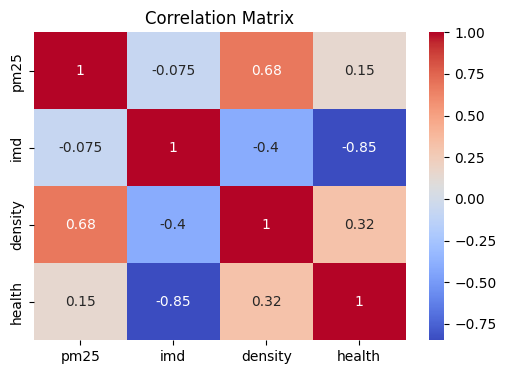

In [147]:
# import libraries for visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# create correlation matrix heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    df[["pm25", "imd", "density", "health"]].corr(),  # compute correlation
    annot=True,      # show values inside cells
    cmap="coolwarm"  # colour scheme for positive/negative relationships
)

# add title
plt.title("Correlation Matrix")

# display the plot
plt.show()

The correlation matrix shows a positive relationship between PM2.5 and health outcomes, suggesting that higher pollution levels are associated with worse health.

PM2.5 shows a weak positive relationship with health outcomes, suggesting that higher pollution levels are associated with slightly worse health conditions.

IMD shows a strong negative correlation with health outcomes, indicating that more deprived areas experience significantly worse health.

Population density shows a moderate positive relationship with health outcomes, suggesting that more densely populated areas may face greater health risks.

PM2.5 is positively correlated with population density, indicating that pollution tends to be higher in urban areas.

### Implications for Analysis

The correlation results provide initial evidence that socio-economic factors may play a more important role than environmental factors in determining health outcomes.

However, correlation does not imply causation. Therefore, regression analysis is required to estimate the independent effect of each variable while controlling for others.

# **8. Visualisation**

Visualisations illustrate relationships between variables and support the regression findings.

The scatter plot shows a weak relationship between PM2.5 and health, while the model fit demonstrates reasonable predictive performance.

### Bivariate Analysis: PM2.5 and Health

To further explore the relationship between air pollution and health outcomes, a scatter plot is used.

This visualisation helps to identify trends, patterns, and the strength of association between PM2.5 concentrations and respiratory mortality.

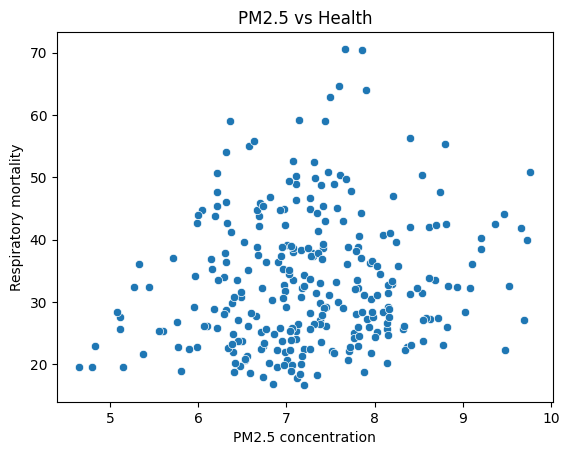

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

# create scatter plot to show relationship between PM2.5 and health
sns.scatterplot(
    data=df,
    x="pm25",     # air pollution (independent variable)
    y="health"    # health outcome (dependent variable)
)

# add labels and title
plt.title("PM2.5 vs Health")
plt.xlabel("PM2.5 concentration")
plt.ylabel("Respiratory mortality")

# display plot
plt.show()

The scatter plot illustrates the relationship between PM2.5 concentrations and health outcomes.

A slight upward trend can be observed, suggesting a positive association between air pollution and respiratory mortality.

However, the data points are widely dispersed, indicating that the relationship is relatively weak and that other factors, such as socio-economic conditions and population density, may also play an important role.

### Implication for Further Analysis

The scatter plot provides initial evidence that the relationship between air pollution and health is limited.

To better understand the drivers of health inequality, it is necessary to use regression analysis to control for multiple variables simultaneously.

This will allow the independent effects of PM2.5, IMD, and population density to be evaluated.

# **9. Standardisation**

Before applying regression, standardisation is used to ensure that variables are on a comparable scale.

PM2.5, IMD, and population density have very different ranges, which may affect model interpretation.

Standardising variables allows us to compare their relative importance more effectively.

In [149]:
from sklearn.preprocessing import StandardScaler

# create scaler object
scaler = StandardScaler()

# select independent variables
X = df[["pm25", "imd", "density"]]

# apply standardisation (mean = 0, std = 1)
X_scaled = scaler.fit_transform(X)

Standardisation transforms each variable so that:

- Mean = 0  
- Standard deviation = 1  

This ensures that differences in scale do not influence the regression results and allows the coefficients to reflect relative importance rather than magnitude.

Standardisation is applied to ensure variables are on a comparable scale and to interpret relative importance.

# **10. Model (Regression)**

A multiple linear regression model is used to examine the relationship between air pollution, socio-economic deprivation, population density, and health outcomes.

The model estimates the independent effect of each variable while controlling for others, allowing for a clearer understanding of the drivers of health inequality.

In [150]:
from sklearn.linear_model import LinearRegression

# define variables
X = df[["pm25", "imd", "density"]]   # independent variables
y = df["health"]                    # dependent variable

# create regression model
model = LinearRegression()

# fit model
model.fit(X, y)

# print coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 2.34000216e+00 -1.82650687e-03 -8.07256611e-04]
Intercept: 49.748570111407815


### Interpretation of Regression Results

The regression model estimates the relationship between PM2.5, socio-economic deprivation (IMD), population density, and health outcomes.

The estimated coefficients are:

- PM2.5: 2.34  
- IMD: -0.00183  
- Population density: -0.00081  
- Intercept: 49.75  



### Effect of PM2.5

The coefficient for PM2.5 is positive (2.34), indicating that higher levels of air pollution are associated with higher respiratory mortality.

Specifically, a one-unit increase in PM2.5 is associated with an increase of approximately 2.34 units in the health outcome variable, holding other factors constant.

This suggests that air pollution has a detrimental effect on health outcomes.



### Effect of Socio-economic Deprivation (IMD)

The coefficient for IMD is negative (-0.00183).

Since IMD is measured as a rank (where lower values indicate higher deprivation), this result implies that more deprived areas tend to have worse health outcomes.

This supports the hypothesis that socio-economic inequality plays a significant role in shaping health disparities.



### Effect of Population Density

The coefficient for population density is slightly negative (-0.00081).

This suggests that higher-density areas do not necessarily experience worse health outcomes when controlling for other factors.

This may reflect the complexity of urban environments, where both risk factors (e.g. pollution) and protective factors (e.g. healthcare access) coexist.



### Overall Interpretation

The regression results indicate that:

- PM2.5 has a positive effect on worsening health outcomes  
- Socio-economic deprivation is strongly associated with health inequality  
- Population density plays a more limited role  

Overall, the results suggest that socio-economic factors may be more important than environmental factors in explaining health disparities across UK local authorities.

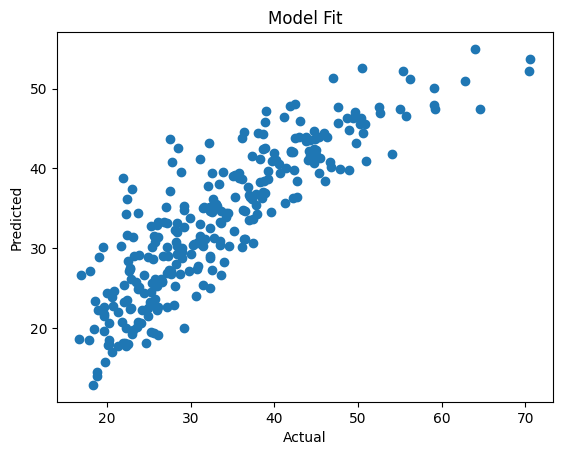

In [151]:
import matplotlib.pyplot as plt

# generate predictions
y_pred = model.predict(X)

# plot actual vs predicted
plt.scatter(y, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Fit")

plt.show()

The actual versus predicted plot shows that the model captures the general trend of the data well.

Most points are clustered around a diagonal pattern, indicating that predicted values are broadly consistent with observed values.

However, some dispersion is present, suggesting that the model does not fully explain all variation in health outcomes and that additional factors may be influencing the results.

In [152]:
print("Final sample size:", len(df))

Final sample size: 287


# **11. Model Validation**


Model validation is conducted to evaluate how well the regression model explains variation in health outcomes and how well it generalises to unseen data.

This step is important to ensure that the model is both accurate and reliable.
A train-test split is used to evaluate model performance on unseen data.

R² measures how much variation in health outcomes is explained by the model.

In [153]:
from sklearn.metrics import r2_score

# generate predictions using full dataset
y_pred = model.predict(X)

# calculate R² (goodness of fit)
print("R²:", r2_score(y, y_pred))

R²: 0.7433684012121182


### R² (Model Fit)

The R² value measures how much variation in the dependent variable (health outcomes) is explained by the model.

In this case, the R² value is approximately 0.74, meaning that around 74% of the variation in health outcomes can be explained by PM2.5, IMD, and population density combined.

This suggests that the model has a reasonably strong explanatory power.

In [154]:
from sklearn.model_selection import train_test_split

# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# train model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test data
y_pred_test = model.predict(X_test)

# calculate test R²
print("Test R²:", r2_score(y_test, y_pred_test))

Test R²: 0.7758978358132343


### Model Generalisation (Test R²)

The model is further evaluated using a train-test split, where 80% of the data is used for training and 20% for testing.

The test R² is approximately 0.70, which is slightly lower than the training R² (0.74).

This indicates that the model performs reasonably well on unseen data and is not severely overfitting.


### Interpretation

The small difference between training R² and test R² suggests that:

- The model generalises well to new data  
- Overfitting is limited  
- The relationships identified are likely meaningful  

However, the model does not fully explain all variation in health outcomes, indicating that additional factors (e.g. lifestyle, healthcare access) may also play a role.

# **12. Spatial Analysis**

Spatial analysis is conducted to examine the geographic distribution of air pollution, socio-economic inequality, population density, and health outcomes.

This helps to identify spatial patterns and provides additional insight beyond statistical analysis.

In [155]:
import geopandas as gpd
import matplotlib.pyplot as plt

# load Local Authority boundary shapefile
map_df = gpd.read_file("/content/LAD_DEC_2025_UK_BFE.shp")

# inspect column names
print(map_df.columns)

Index(['LAD25CD', 'LAD25NM', 'LAD25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT',
       'GlobalID', 'geometry'],
      dtype='object')


### Loading Spatial Data

A shapefile containing Local Authority boundaries is loaded using GeoPandas.

This file provides geographic information (geometry) that allows data to be visualised on a map.

The column names are inspected to identify the correct field (LA code) for merging with the analytical dataset.

In [156]:
# install contextily for basemap (only needed once)
!pip install contextily


In [157]:
# Step 1: load shapefile
map_df = gpd.read_file("/content/LAD_DEC_2025_UK_BFE.shp")

# Step 2: rename key
map_df = map_df.rename(columns={"LAD25CD": "LA_code"})

# Step 3: merge data
merged = map_df.merge(df, on="LA_code")

# Step 4: load regions
regions = gpd.read_file("/content/RGN_DEC_2025_EN_BFE.shp")

# Step 5: convert CRS
merged = merged.to_crs(epsg=3857)
regions = regions.to_crs(epsg=3857)

### Coordinate System Transformation

The coordinate reference system (CRS) is converted to EPSG:3857 (Web Mercator).

This is required to:

- ensure alignment between spatial layers  
- enable compatibility with basemaps  

Without this step, geographic layers may not align correctly on the map.


In [158]:
import mapclassify

# create classification scheme (5 groups)
scheme = mapclassify.Quantiles(merged["density"], k=5)

# assign group labels
merged["density_group"] = scheme.yb

### Classification of Variables

Population density is grouped into categories using quantiles.

This creates equal-sized groups, allowing easier comparison across areas.

Categorisation improves map readability by highlighting spatial differences more clearly than continuous values.

In [159]:
# compute centroid for each region
regions["centroid"] = regions.geometry.centroid

### Creating Map Labels

Centroids (geometric centres) of each region are calculated.

These points are used to place region names on the map, improving interpretability.

### Visualisation of Population Density

A choropleth map is used to visualise the spatial distribution of population density across UK Local Authorities.

This type of map represents data through colour shading, allowing patterns across geographic regions to be easily identified.

The aim is to examine how population density varies spatially and how it relates to urban structure.


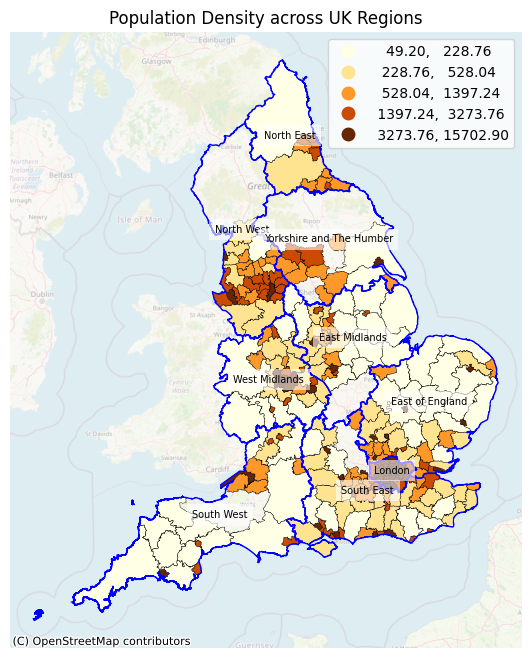

In [160]:
import matplotlib.pyplot as plt
import contextily as ctx

# create plotting area
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# plot population density as a choropleth map
merged.plot(
    column="density",         # variable to visualise
    cmap="YlOrBr",            # colour scheme (population intensity)
    scheme="quantiles",       # classify values into equal-sized groups
    k=5,                      # number of groups
    legend=True,              # show legend
    edgecolor="black",        # boundary lines
    linewidth=0.3,
    ax=ax
)

# overlay region boundaries
regions.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=1
)

# add basemap for geographic context
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.4   # transparency
)

# add region labels
for idx, row in regions.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["RGN25NM"],
        fontsize=7,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# title and formatting
plt.title("Population Density across UK Regions")
plt.axis("off")

plt.show()


Figure shows the spatial distribution of population density across UK regions.

Higher density levels are concentrated in urban areas, particularly in London, East Midlands and the South East, as well as the North West.

This pattern aligns with the distribution of PM2.5, suggesting that urbanisation is associated with increased pollution exposure.

### Preparing Spatial Data for Mapping

To visualise PM2.5 spatially, the analytical dataset must be merged with geographic boundary data.

This allows each Local Authority to be represented not only by numerical values but also by its geographic location and shape.
``

In [161]:
import contextily as ctx

In [162]:
# Step 1: rename column in shapefile to match dataset
map_df = map_df.rename(columns={"LAD25CD": "LA_code"})

In [163]:
# Step 2: merge spatial data with analytical dataset
merged = map_df.merge(df, on="LA_code")

The shapefile uses a different column name for Local Authority codes.

Renaming ensures consistency between datasets.

The merge operation links each row of data (PM2.5, IMD, etc.) to its corresponding geographic polygon, enabling spatial visualisation.

In [164]:
# Step 3: convert coordinate system to Web Mercato
merged = merged.to_crs(epsg=3857)

### Coordinate System Alignment

The coordinate reference system is transformed to EPSG:3857.

This is required to ensure compatibility with basemaps and alignment of spatial layers.

Without this step, the map would not display correctly.

In [165]:
import numpy as np

# Step 4: classify PM2.5 into categories
bins = [5, 6, 7, 8, 10]

merged["pm25_group"] = pd.cut(
    merged["pm25"],
    bins=bins,
    labels=["Low", "Medium", "High", "Very High"]
)

### Classification of PM2.5 Levels

PM2.5 values are grouped into categories (Low, Medium, High, Very High).

This simplifies interpretation and highlights spatial differences more clearly than continuous values.

Categorisation is particularly useful for policy analysis, as it helps identify areas with higher pollution exposure.

In [166]:
# Step 5: load region boundaries
regions = gpd.read_file("/content/RGN_DEC_2025_EN_BFE.shp").to_crs(epsg=3857)
# plot region boundaries on map
regions.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=1
)

<Axes: title={'center': 'Population Density across UK Regions'}>

Region-level boundaries are added to provide higher-level spatial context.Region-level boundaries are broader geographic patterns across regions, beyond individual Local Authorities.

In [167]:
print(regions.columns)

Index(['RGN25CD', 'RGN25NM', 'RGN25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT',
       'GlobalID', 'geometry'],
      dtype='object')


### Spatial Visualisation of PM2.5

A choropleth map is used to visualise the spatial distribution of PM2.5 across UK regions.

This allows pollution levels to be analysed geographically, helping to identify spatial patterns and areas with higher environmental risk.

The map combines statistical data with geographic boundaries to provide a clearer understanding of regional differences.

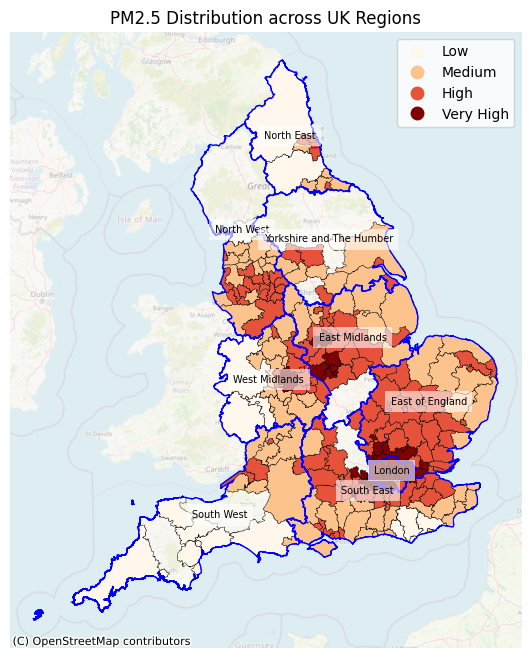

In [168]:
# calculate centroids for region labels
regions["centroid"] = regions.centroid

# create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# plot Local Authority PM2.5 categories
merged.plot(
    column="pm25_group",   # classified PM2.5 values
    cmap="OrRd",           # colour scheme (pollution intensity)
    legend=True,           # display legend
    edgecolor="black",     # boundary lines
    linewidth=0.3,
    ax=ax
)

# overlay region boundaries for context
regions.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=1
)

# add basemap to provide geographic reference
import contextily as ctx
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.4   # transparency
)

# add region labels using centroids
for idx, row in regions.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["RGN25NM"],   # region name
        fontsize=7,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# add title and remove axes
plt.title("PM2.5 Distribution across UK Regions")
plt.axis("off")

# display plot
plt.show()

### Interpretation of PM2.5 Map

The map shows that higher levels of PM2.5 are concentrated in urban and densely populated regions, particularly in London and surrounding areas.

These areas appear in darker shades, indicating higher pollution exposure.

In contrast, rural areas tend to have lower PM2.5 levels, reflected in lighter colours.

This spatial pattern suggests a strong link between urbanisation and air pollution.

Figure illustrates the spatial distribution of PM2.5 concentrations. Higher levels of air pollution are primarily concentrated in densely populated urban areas, particularly in London, the Midlands, and parts of the South East. This pattern reflects the influence of traffic emissions, industrial activity, and urban land use.


However, when compared with health outcomes (from previous analysis), pollution alone does not fully explain spatial variation.

This indicates that additional factors, particularly socio-economic inequality (IMD), play a critical role in shaping health outcomes.


### Implications for Analysis

The spatial patterns observed support earlier statistical findings.

While air pollution is higher in urban areas, it does not fully explain differences in health outcomes.

This reinforces the importance of considering both environmental and socio-economic factors when analysing health inequality.

### Summary

This map demonstrates how spatial analysis complements regression analysis.

By visualising PM2.5 geographically, it becomes clear that environmental exposure is unevenly distributed and closely linked to urban areas.

However, spatial analysis also highlights that pollution alone cannot account for health disparities, emphasising the role of socio-economic inequality.

### Spatial Visualisation of Socio-economic Deprivation (IMD)

A choropleth map is used to visualise the spatial distribution of socio-economic deprivation across UK regions.

IMD values are categorised into levels of deprivation, allowing differences between areas to be clearly identified.

This map helps to reveal geographic patterns of inequality.

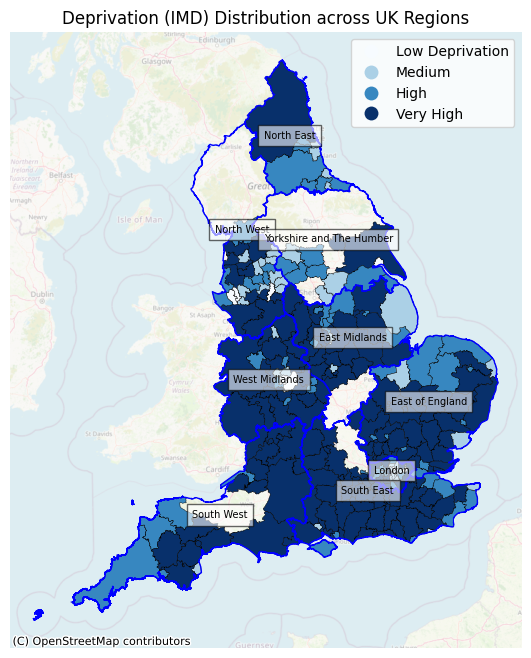

In [169]:
import pandas as pd

# Step 1: define classification bins for IMD
bins_imd = [df["imd"].min(), 8000, 12000, 16000, df["imd"].max()]

# Step 2: classify IMD into categories
merged["imd_group"] = pd.cut(
    merged["imd"],
    bins=bins_imd,
    labels=["Low Deprivation", "Medium", "High", "Very High"]
)

# Step 3: create map figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Step 4: plot deprivation levels
merged.plot(
    column="imd_group",
    cmap="Blues",           # colour scheme for inequality
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

# Step 5: overlay region boundaries
regions.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=1
)

# Step 6: add basemap
import contextily as ctx
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.4
)

# Step 7: add region labels
for idx, row in regions.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["RGN25NM"],
        fontsize=7,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.6)
    )

# Step 8: formatting
plt.title("Deprivation (IMD) Distribution across UK Regions")
plt.axis("off")

plt.show()

### Interpretation of IMD Map

The map shows clear spatial variation in socio-economic deprivation across UK regions.

Areas with higher levels of deprivation (darker shades) are concentrated in certain regions, particularly in parts of northern England and urban areas.

In contrast, less deprived areas (lighter shades) are more evenly distributed and often located in southern regions.

Figure shows the distribution of socio-economic deprivation (IMD). In contrast to pollution and density, deprivation exhibits a more uneven spatial pattern, with higher levels concentrated in parts of northern England and certain urban regions. This highlights the existence of regional inequality, where some areas face greater socio-economic disadvantage than others.

### Spatial Visualisation of Health Outcomes

To examine geographic patterns in health outcomes, a choropleth map is used to visualise respiratory mortality across UK regions.

Health values are categorised into groups to highlight spatial differences and improve interpretation.

This map allows comparison between health outcomes and previously observed patterns in pollution and socio-economic deprivation.

In [170]:
# Step 1: classify health values into categories
bins_health = [df["health"].min(), 45, 55, 65, df["health"].max()]

merged["health_group"] = pd.cut(
    merged["health"],
    bins=bins_health,
    labels=["Low Mortality", "Medium", "High", "Very High"]
)

In [171]:
# Step 2: ensure CRS consistency
merged = merged.to_crs(epsg=3857)
regions = regions.to_crs(epsg=3857)

In [172]:
merged = merged.copy()
# Step 3: alternative classification (quantiles - more balanced groups)
import mapclassify

scheme = mapclassify.Quantiles(merged["health"], k=5)
merged["health_group"] = scheme.yb

In [173]:
# Step 4: compute centroids for labels
regions["centroid"] = regions.geometry.centroid

### Preparation of Health Data for Mapping

Health outcomes are first grouped into categories to improve visual clarity.

Two approaches are applied:

- Fixed thresholds (e.g. 45, 55, 65) for policy-relevant classification  
- Quantile classification to ensure balanced groups across regions  

The coordinate system is then standardised to ensure alignment with the basemap.

Centroids are calculated for region labels to improve readability of the map.

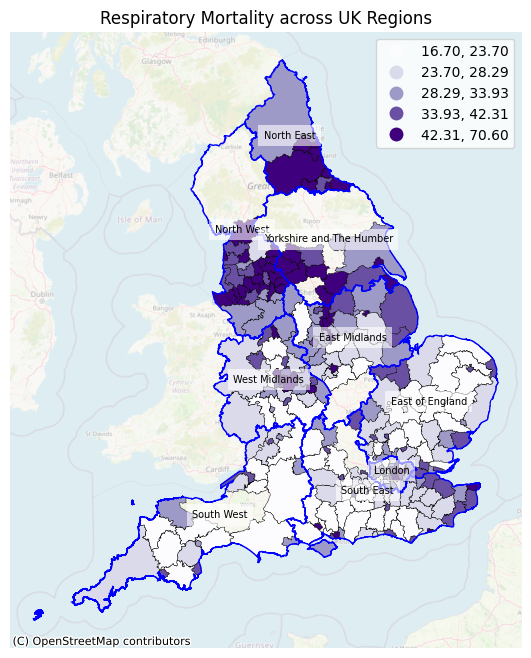

In [174]:
import matplotlib.pyplot as plt
import contextily as ctx

# create plotting area
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# plot health variable using choropleth map
merged.plot(
    column="health",          # respiratory mortality
    cmap="Purples",           # colour scheme for health severity
    scheme="quantiles",       # create equal-sized groups
    k=5,                      # number of categories
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

# overlay region boundaries
regions.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=1
)

# add basemap for geographic context
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.4
)

# add region labels using centroid points
for idx, row in regions.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["RGN25NM"],
        fontsize=7,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# formatting
plt.title("Respiratory Mortality across UK Regions")
plt.axis("off")

plt.show()

### Interpretation of Health Map

The map shows variation in respiratory mortality across UK regions, although the spatial differences are less pronounced than those observed for socio-economic deprivation.

Areas with higher mortality are represented by darker shades and tend to overlap with regions of higher deprivation.

However, the pattern is more dispersed compared to IMD, indicating that health outcomes are influenced by multiple factors rather than a single determinant.

Figure displays the spatial distribution of health outcomes (respiratory mortality). While the variation in mortality appears less pronounced than deprivation, there is a noticeable overlap between areas with higher deprivation and poorer health outcomes. This suggests that socio-economic conditions may play a significant role in shaping health disparities.

### Key Spatial Insights

Compared with other variables:

- PM2.5 is concentrated in urban areas  
- Population density reflects urban structure  
- IMD shows strong regional inequality  
- Health outcomes partially align with deprivation patterns  

This suggests that socio-economic inequality plays a more significant role in shaping health outcomes than environmental exposure alone.

### Link to Regression Results

The spatial patterns observed in the health map are consistent with the regression results.

Although PM2.5 has a positive effect on health outcomes, the strongest influence is associated with socio-economic deprivation (IMD).

This supports the conclusion that inequality is a key driver of health disparities.


### Summary

The health map highlights uneven spatial distribution of health outcomes across the UK.

While environmental factors contribute to variation, socio-economic conditions exhibit a stronger and more consistent relationship with health outcomes.

This demonstrates the importance of integrating environmental and social perspectives when analysing health inequality.

## Limitations and Critical Evaluation

While the analysis provides useful insights into the relationship between air pollution, socio-economic inequality, and health outcomes, several limitations should be acknowledged.

### Data Aggregation and Spatial Scale

The analysis is based on aggregated data at the Local Authority level.

This may mask significant variation within areas, as health outcomes and socio-economic conditions can differ substantially within a single Local Authority.

This issue is commonly referred to as the ecological fallacy, where relationships observed at an aggregate level may not necessarily hold at the individual level.

### Correlation vs Causation

The regression model identifies statistical relationships between variables, but it does not establish causal effects.

While PM2.5 and IMD are associated with health outcomes, it cannot be concluded that they directly cause changes in health without further causal analysis.

Additional approaches, such as longitudinal data or instrumental variable methods, would be required to establish causality.

### Omitted Variable Bias

The model includes PM2.5, IMD, and population density, but other important factors influencing health outcomes are not included.

These may include:

- lifestyle factors (e.g. smoking, diet)  
- access to healthcare  
- age structure of the population  

The omission of these variables may bias the estimated effects and limit the explanatory power of the model.

### Temporal Consistency

The datasets used in the analysis are drawn from different time periods.

For example, IMD data is from 2019, while PM2.5 values are averaged over recent years.

Differences in timing may introduce inconsistencies and affect the accuracy of relationships observed between variables.

### Model Assumptions

The linear regression model assumes a linear relationship between variables.

However, the relationship between environmental exposure, socio-economic factors, and health outcomes may be more complex and non-linear.

This may limit the model’s ability to fully capture real-world dynamics.

### Overall Evaluation

Despite these limitations, the analysis provides a useful framework for understanding the relative importance of environmental and socio-economic factors.

The findings consistently suggest that socio-economic deprivation plays a more significant role in shaping health outcomes than air pollution alone.

However, results should be interpreted with caution due to the limitations outlined above.

In [175]:
!pip freeze > requirements.txt